# 05 - Forecasting
Forecast 7 indikator ekonomi pakai ARIMA, lalu pipe ke 4 model ML untuk GDP forecast otomatis.

In [8]:
import pandas as pd
import numpy as np
import joblib
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/processed/dataset_indonesia.csv')
print('Data loaded:', df.shape)
print(df.tail(3))


Data loaded: (34, 9)
    Year  GDP_Growth  Inflation  Unemployment  Population_Growth    Exports  \
31  2022    5.307197   4.209465         3.462           0.746050  24.502912   
32  2023    5.049023   3.669387         3.308           0.842666  21.753847   
33  2024    5.030345   2.181513         3.301           0.813872  22.183313   

      Imports       FDI  Exchange_Rate  
31  20.961759  1.872641   14849.853936  
32  19.582440  1.571167   15236.884662  
33  20.389334  1.738555   15855.448287  


In [9]:
# ── Step 1: Forecast setiap indikator pakai ARIMA + tren historis ──
INDICATORS = ['Inflation', 'Unemployment', 'Population_Growth',
              'Exports', 'Imports', 'FDI', 'Exchange_Rate']

FORECAST_YEARS = list(range(2025, 2031))
N_FORECAST = len(FORECAST_YEARS)

indicator_forecasts = {}
arima_orders = {}

for col in INDICATORS:
    series = df[col].values

    # Hitung tren historis: rata-rata perubahan per tahun (5 tahun terakhir)
    recent = series[-5:]
    annual_trend = np.mean(np.diff(recent))

    best_aic = np.inf
    best_order = (1, 1, 1)

    # Grid search order ARIMA
    for p in range(0, 3):
        for d in range(0, 2):
            for q in range(0, 3):
                try:
                    model = ARIMA(series, order=(p, d, q))
                    res   = model.fit()
                    if res.aic < best_aic:
                        best_aic   = res.aic
                        best_order = (p, d, q)
                except:
                    continue

    # Fit dengan order terbaik
    model  = ARIMA(series, order=best_order)
    result = model.fit()
    fc_base = result.forecast(steps=N_FORECAST)

    # Gabungkan ARIMA + tren historis
    # Jika ARIMA flat (range < 0.01), paksa pakai tren historis
    fc_range = float(np.max(fc_base) - np.min(fc_base))
    yearly = []
    for i, v in enumerate(fc_base):
        if fc_range < 0.01:
            # ARIMA konstan → pakai tren historis
            val = float(series[-1]) + annual_trend * (i + 1)
        else:
            # ARIMA sudah punya variasi → pakai langsung
            val = float(v)
        yearly.append(round(val, 6))

    indicator_forecasts[col] = yearly
    arima_orders[col] = best_order
    print(f'{col:25s} order={best_order}  trend={annual_trend:+.3f}  forecast={[round(v,2) for v in yearly]}')

print('\nSemua indikator berhasil di-forecast!')

Inflation                 order=(0, 1, 1)  trend=+0.065  forecast=[2.25, 2.31, 2.38, 2.44, 2.51, 2.57]
Unemployment              order=(0, 1, 0)  trend=-0.238  forecast=[3.06, 2.82, 2.59, 2.35, 2.11, 1.87]
Population_Growth         order=(0, 1, 1)  trend=-0.009  forecast=[0.8, 0.8, 0.79, 0.78, 0.77, 0.76]
Exports                   order=(0, 1, 1)  trend=+1.213  forecast=[23.4, 24.61, 25.82, 27.04, 28.25, 29.46]
Imports                   order=(0, 1, 1)  trend=+1.187  forecast=[21.58, 22.76, 23.95, 25.14, 26.32, 27.51]
FDI                       order=(0, 1, 0)  trend=-0.018  forecast=[1.72, 1.7, 1.68, 1.67, 1.65, 1.63]
Exchange_Rate             order=(0, 1, 0)  trend=+318.311  forecast=[16173.76, 16492.07, 16810.38, 17128.69, 17447.0, 17765.32]

Semua indikator berhasil di-forecast!


In [10]:
# ── Step 2: Susun DataFrame forecast indikator ─────────────────────
df_future = pd.DataFrame(indicator_forecasts, index=FORECAST_YEARS)
df_future.index.name = 'Year'
print('DataFrame forecast indikator:')
print(df_future.round(3).to_string())


DataFrame forecast indikator:
      Inflation  Unemployment  Population_Growth  Exports  Imports    FDI  Exchange_Rate
Year                                                                                    
2025      2.247         3.062              0.805   23.396   21.576  1.721      16173.759
2026      2.312         2.824              0.796   24.609   22.763  1.703      16492.071
2027      2.378         2.586              0.787   25.822   23.951  1.685      16810.382
2028      2.443         2.347              0.778   27.035   25.138  1.667      17128.693
2029      2.509         2.108              0.769   28.248   26.325  1.649      17447.004
2030      2.574         1.870              0.760   29.462   27.512  1.631      17765.316


In [11]:
# ── Step 3: Load semua model ML + scaler ───────────────────────────
with open('../models/data_split.pkl', 'rb') as f:
    data_split = pickle.load(f)

scaler   = joblib.load('../models/scaler.pkl')
FEATURES = data_split['features']

MODEL_FILES = {
    'Linear Regression': 'linear_regression.pkl',
    'Ridge Regression':  'ridge_regression.pkl',
    'Decision Tree':     'decision_tree.pkl',
    'Random Forest':     'random_forest.pkl',
}

ml_models = {}
for name, fname in MODEL_FILES.items():
    path = f'../models/{fname}'
    if os.path.exists(path):
        ml_models[name] = joblib.load(path)
        print(f'Loaded: {name}')
    else:
        print(f'SKIP (tidak ada): {fname}')

print(f'\nModel tersedia: {list(ml_models.keys())}')


Loaded: Linear Regression
Loaded: Ridge Regression
Loaded: Decision Tree
Loaded: Random Forest

Model tersedia: ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest']


In [12]:
# ── Step 4: Pipe forecast indikator → GDP forecast ─────────────────
gdp_forecasts = {}   # {nama_model: [gdp2025, gdp2026, ...]}

for model_name, model in ml_models.items():
    yearly_preds = []
    for year in FORECAST_YEARS:
        row    = df_future.loc[year, FEATURES].values.reshape(1, -1)
        scaled = scaler.transform(row)
        pred   = model.predict(scaled)[0]
        yearly_preds.append(round(float(pred), 4))
    gdp_forecasts[model_name] = yearly_preds
    print(f'{model_name:25s}: {yearly_preds}')

print('\nGDP forecast selesai!')


Linear Regression        : [2.9288, 2.6199, 2.311, 2.0021, 1.6931, 1.3842]
Ridge Regression         : [3.6748, 3.3169, 2.9589, 2.601, 2.2431, 1.8852]
Decision Tree            : [5.5988, 5.5988, 5.5988, 5.5988, 5.5988, 5.5988]
Random Forest            : [5.229, 5.3263, 5.3343, 5.3343, 5.3343, 5.3343]

GDP forecast selesai!


In [13]:
# ── Step 5: Simpan hasil ke forecast_report.json ───────────────────
with open('../models/model_report.json') as f:
    model_report = json.load(f)

best_model_name = model_report['best_model']

forecast_report = {
    'forecast_years':       FORECAST_YEARS,
    'indicator_forecasts':  indicator_forecasts,
    'arima_orders':         {k: list(v) for k, v in arima_orders.items()},
    'gdp_forecasts':        gdp_forecasts,
    'best_model':           best_model_name,
    'gdp_historical': {
        'years':  df['Year'].tolist(),
        'values': df['GDP_Growth'].tolist()
    }
}

with open('../models/forecast_report.json', 'w') as f:
    json.dump(forecast_report, f, indent=2)

print('forecast_report.json disimpan!')
print(f'Tahun forecast : {FORECAST_YEARS}')
print(f'Model tersedia : {list(gdp_forecasts.keys())}')
print(f'Best model     : {best_model_name}')


forecast_report.json disimpan!
Tahun forecast : [2025, 2026, 2027, 2028, 2029, 2030]
Model tersedia : ['Linear Regression', 'Ridge Regression', 'Decision Tree', 'Random Forest']
Best model     : Random Forest


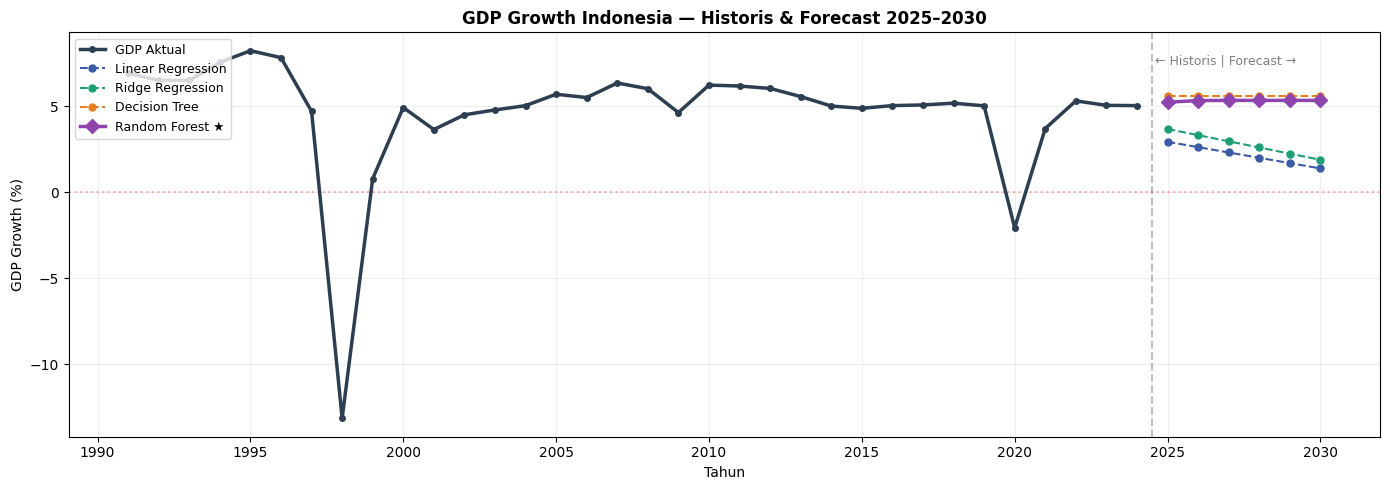

Plot disimpan!


In [14]:
# ── Step 6: Plot GDP historis + forecast semua model ───────────────
import matplotlib.pyplot as plt

hist_years  = df['Year'].tolist()
hist_values = df['GDP_Growth'].tolist()

colors = {
    'Linear Regression': '#3B5BA5',
    'Ridge Regression':  '#1D9E75',
    'Decision Tree':     '#E67E22',
    'Random Forest':     '#8E44AD',
}

fig, ax = plt.subplots(figsize=(14, 5))

# Historis
ax.plot(hist_years, hist_values, color='#2C3E50', linewidth=2.5,
        marker='o', markersize=4, label='GDP Aktual', zorder=5)

# Garis pemisah
ax.axvline(x=2024.5, color='gray', linestyle='--', alpha=0.5)
ax.text(2024.6, max(hist_values)*0.9, '← Historis | Forecast →',
        fontsize=9, color='gray')

# Forecast tiap model
for model_name, preds in gdp_forecasts.items():
    is_best = model_name == best_model_name
    ax.plot(FORECAST_YEARS, preds,
            color=colors.get(model_name, '#888'),
            linewidth=2.5 if is_best else 1.5,
            linestyle='-' if is_best else '--',
            marker='D' if is_best else 'o',
            markersize=7 if is_best else 5,
            label=f'{model_name}{" ★" if is_best else ""}')

ax.axhline(y=0, color='red', linestyle=':', alpha=0.3)
ax.set_title('GDP Growth Indonesia — Historis & Forecast 2025–2030', fontweight='bold')
ax.set_xlabel('Tahun')
ax.set_ylabel('GDP Growth (%)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.2)
plt.tight_layout()

os.makedirs('../data/eda_outputs', exist_ok=True)
plt.savefig('../data/eda_outputs/gdp_forecast.png', dpi=150)
plt.show()
print('Plot disimpan!')
